# Rossmann Store Sales — Етап 2: EDA на рівні всієї мережі

Цей ноутбук реалізує **Етап 2** плану аналізу: дослідження загальних трендів, сезонності та первинну перевірку гіпотез Г1-Г2 на рівні всієї мережі (без розбиття на сегменти — це буде в Етапі 3).

**Вхідний файл:** `rossmann_clean.csv` (результат Етапу 1, ноутбук `01_data_cleaning.ipynb`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Завантаження очищених даних

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"], low_memory=False)
print(f"Форма даних: {df.shape[0]:,} рядків, {df.shape[1]} колонок")
print(f"Період: {df['Date'].min().date()} — {df['Date'].max().date()}")


Форма даних: 1,017,209 рядків, 28 колонок
Період: 2013-01-01 — 2015-07-31


In [3]:
# Працюємо лише з відкритими днями — закриті магазини (Sales=0) спотворюють середні
open_df = df[df["Open"] == 1].copy()
print(f"Відкритих днів для аналізу: {open_df.shape[0]:,}")


Відкритих днів для аналізу: 844,392


## 2. Загальні метрики мережі

In [4]:
total_sales = open_df["Sales"].sum()
avg_daily_sales = open_df["Sales"].mean()
median_daily_sales = open_df["Sales"].median()
avg_customers = open_df["Customers"].mean()
avg_sales_per_customer = open_df["SalesPerCustomer"].mean()
cv_sales = open_df["Sales"].std() / open_df["Sales"].mean()

print(f"Сумарні продажі мережі за весь період: {total_sales:,.0f}")
print(f"Середні продажі на магазин/день:       {avg_daily_sales:,.0f}")
print(f"Медіанні продажі на магазин/день:      {median_daily_sales:,.0f}")
print(f"Середня к-сть клієнтів на магазин/день: {avg_customers:,.1f}")
print(f"Середній чек (Sales/Customers):         {avg_sales_per_customer:,.2f}")
print(f"Коефіцієнт варіації продажів (CV):      {cv_sales:.2f}")


Сумарні продажі мережі за весь період: 5,873,180,623
Середні продажі на магазин/день:       6,956
Медіанні продажі на магазин/день:      6,369
Середня к-сть клієнтів на магазин/день: 762.7
Середній чек (Sales/Customers):         9.49
Коефіцієнт варіації продажів (CV):      0.45


**Інтерпретація CV:** коефіцієнт варіації показує, наскільки нестабільні продажі відносно середнього. CV > 0.5 зазвичай означає високу мінливість — це очікувано для роздрібної мережі з денною/тижневою сезонністю та відмінностями між магазинами.

## 3. Динаміка продажів мережі по місяцях

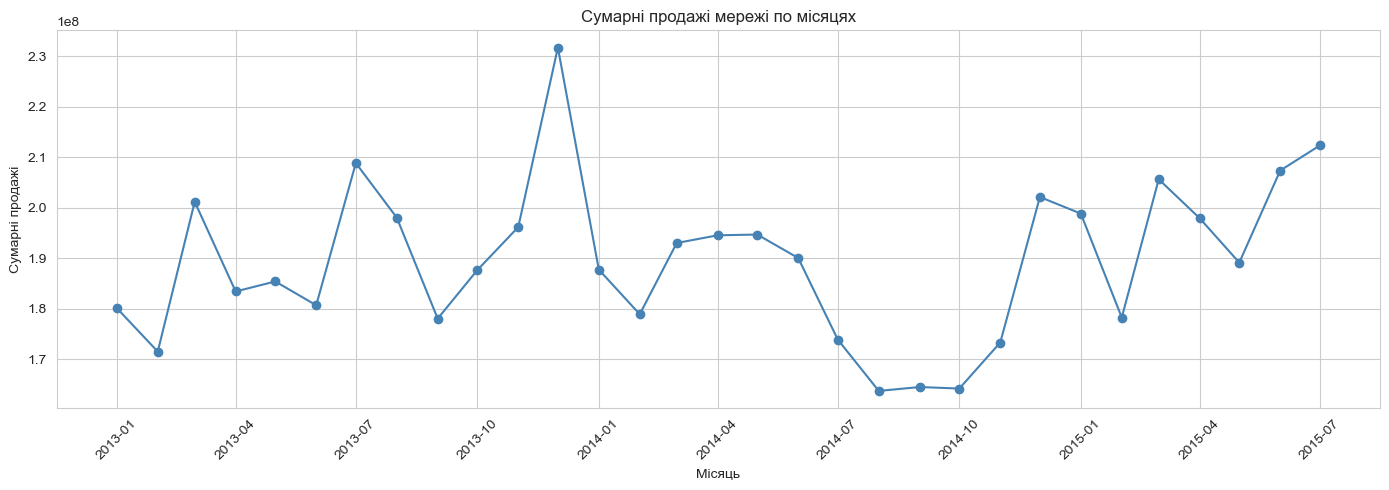

In [5]:
monthly = open_df.groupby(open_df["Date"].dt.to_period("M")).agg(
    total_sales=("Sales", "sum"),
    avg_sales=("Sales", "mean"),
    total_customers=("Customers", "sum")
).reset_index()
monthly["Date"] = monthly["Date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["Date"], monthly["total_sales"], marker="o", color="steelblue")
ax.set_title("Сумарні продажі мережі по місяцях")
ax.set_xlabel("Місяць")
ax.set_ylabel("Сумарні продажі")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("02_monthly_sales_trend.png", dpi=150)
plt.show()


**Що шукаємо:** загальний тренд (зростання/спад мережі рік до року) та повторювані піки — особливо в грудні (перевірка Г2).

## 4. Сезонна декомпозиція

Розкладаємо місячний часовий ряд на тренд, сезонність і залишок — це дозволяє відокремити довгостроковий тренд мережі від регулярної річної сезонності.

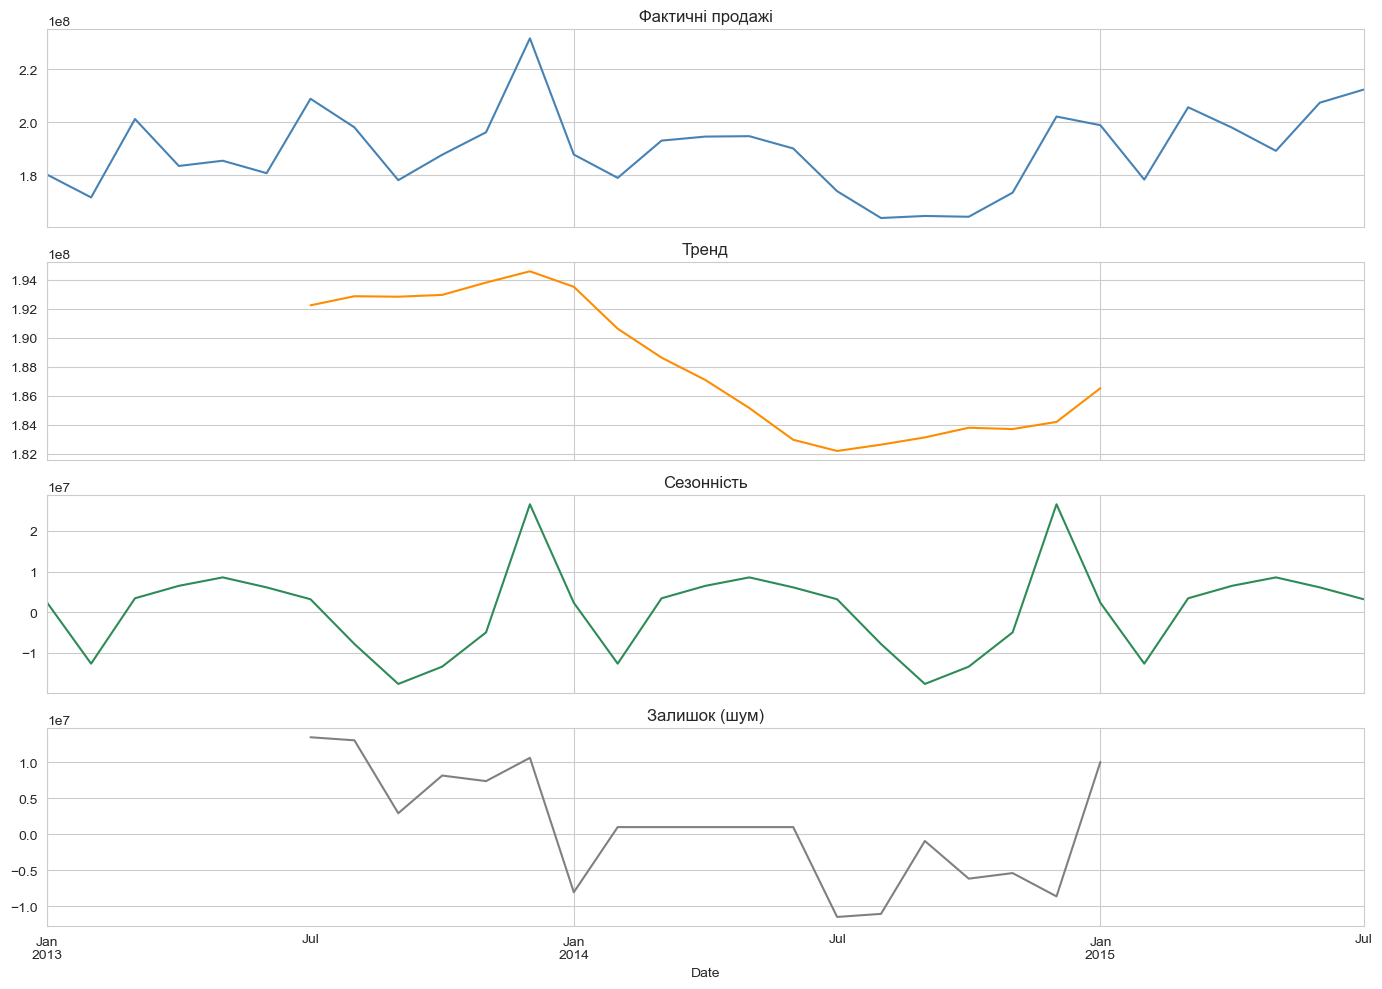

In [6]:
monthly_series = monthly.set_index("Date")["total_sales"]

# Потрібно мінімум 2 повні цикли (24 місяці) для сезонної декомпозиції з period=12
if len(monthly_series) >= 24:
    decomposition = seasonal_decompose(monthly_series, model="additive", period=12)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    decomposition.observed.plot(ax=axes[0], title="Фактичні продажі", color="steelblue")
    decomposition.trend.plot(ax=axes[1], title="Тренд", color="darkorange")
    decomposition.seasonal.plot(ax=axes[2], title="Сезонність", color="seagreen")
    decomposition.resid.plot(ax=axes[3], title="Залишок (шум)", color="gray")
    plt.tight_layout()
    plt.savefig("02_seasonal_decomposition.png", dpi=150)
    plt.show()
else:
    print(f"Недостатньо місяців для декомпозиції з period=12 (є {len(monthly_series)}, потрібно 24+)")


## 5. Heatmap: середні продажі за днем тижня × місяцем

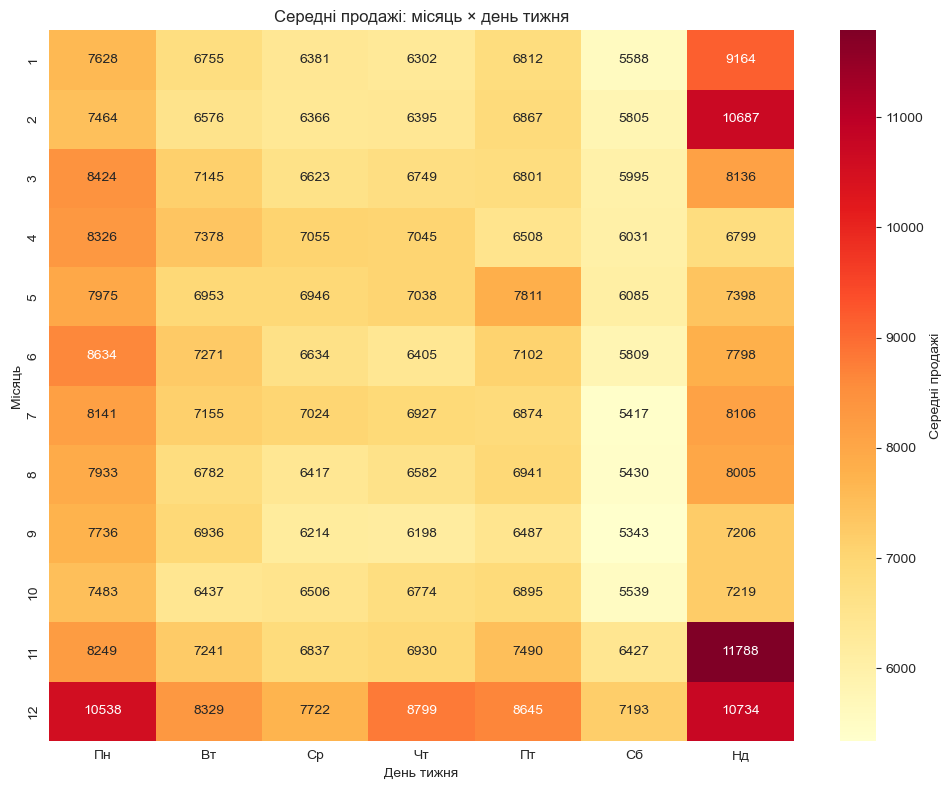

In [7]:
heatmap_data = open_df.groupby(["Month", "DayOfWeek"])["Sales"].mean().unstack()

day_labels = {1: "Пн", 2: "Вт", 3: "Ср", 4: "Чт", 5: "Пт", 6: "Сб", 7: "Нд"}
heatmap_data.columns = [day_labels[d] for d in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Середні продажі"})
ax.set_title("Середні продажі: місяць × день тижня")
ax.set_ylabel("Місяць")
ax.set_xlabel("День тижня")
plt.tight_layout()
plt.savefig("02_heatmap_month_dow.png", dpi=150)
plt.show()


## 6. Продажі за днем тижня

           mean  median          std   count
Пн  8216.073074  7539.0  3691.768876  137560
Вт  7088.113656  6502.0  3066.237110  143961
Ср  6728.122978  6210.0  2781.775174  141936
Чт  6767.310159  6246.0  2764.548119  134644
Пт  7072.677012  6580.0  2764.915744  138640
Сб  5874.840238  5425.0  2852.730426  144058
Нд  8224.723908  6876.0  6235.152960    3593


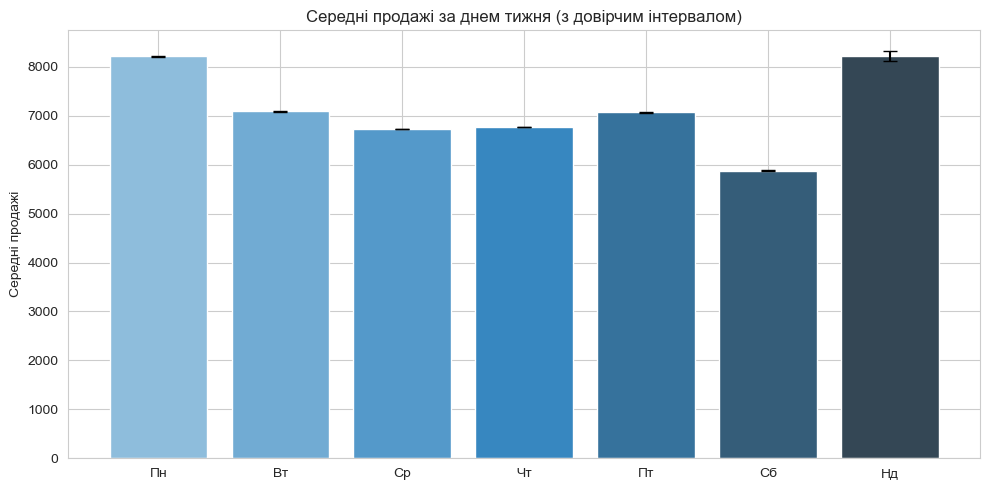

In [8]:
dow_stats = open_df.groupby("DayOfWeek")["Sales"].agg(["mean", "median", "std", "count"])
dow_stats.index = [day_labels[d] for d in dow_stats.index]
print(dow_stats)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Blues_d", len(dow_stats))
ax.bar(dow_stats.index, dow_stats["mean"], yerr=dow_stats["std"] / np.sqrt(dow_stats["count"]),
       color=colors, capsize=5)
ax.set_title("Середні продажі за днем тижня (з довірчим інтервалом)")
ax.set_ylabel("Середні продажі")
plt.tight_layout()
plt.savefig("02_sales_by_dow.png", dpi=150)
plt.show()


**Важлива примітка щодо неділі:** у таблиці вище неділя має лише 3,593 спостереження (проти ~135,000-144,000 в інші дні) і аномально великий розкид (std ≈ 6235). Це тому, що переважна більшість магазинів мережі по неділях закриті — відкриті лише деякі. Тому середнє/медіана для неділі базуються на дуже малій і нерепрезентативній вибірці магазинів (ймовірно, це магазини в туристичних/центральних локаціях з іншою поведінкою покупців), і напряму порівнювати неділю з іншими днями некоректно. При інтерпретації Г1 варто або виключити неділю з порівняння, або аналізувати її окремо як особливий випадок.

## 7. Розподіл середнього чека (SalesPerCustomer)

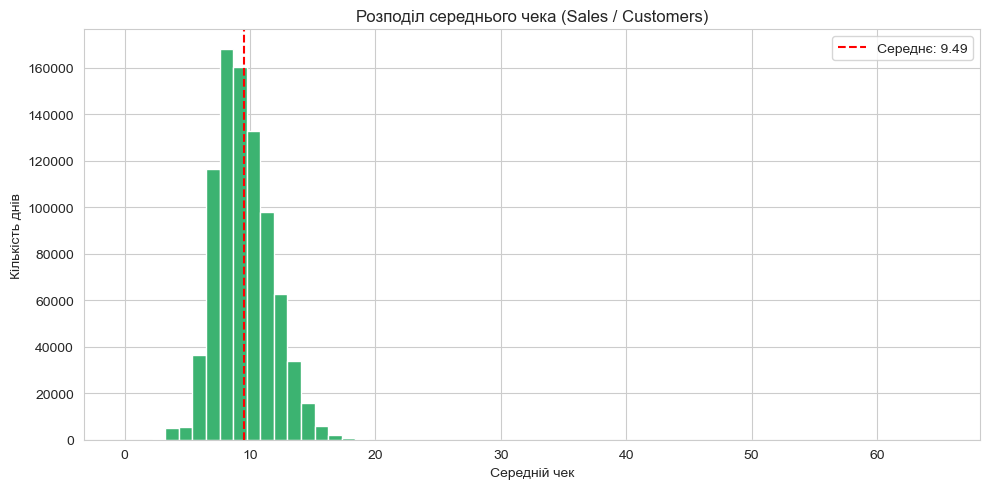

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(open_df["SalesPerCustomer"], bins=60, color="mediumseagreen", edgecolor="white")
ax.axvline(open_df["SalesPerCustomer"].mean(), color="red", linestyle="--", label=f"Середнє: {open_df['SalesPerCustomer'].mean():.2f}")
ax.set_title("Розподіл середнього чека (Sales / Customers)")
ax.set_xlabel("Середній чек")
ax.set_ylabel("Кількість днів")
ax.legend()
plt.tight_layout()
plt.savefig("02_sales_per_customer_hist.png", dpi=150)
plt.show()


## 8. Перевірка гіпотез

### Г1: Продажі мають виражену тижневу сезонність (відмінності між днями тижня статистично значущі)

Використовуємо **Kruskal-Wallis тест** замість класичного ANOVA, оскільки розподіл продажів зазвичай не нормальний (перевіримо це також).

In [10]:
# Перевірка нормальності розподілу продажів (для вибору коректного тесту)
sample = open_df["Sales"].sample(min(5000, len(open_df)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk тест на нормальність (вибірка n=5000): statistic={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")
print("Висновок:", "розподіл НЕ нормальний (p < 0.05)" if shapiro_p < 0.05 else "розподіл нормальний (p >= 0.05)")


Shapiro-Wilk тест на нормальність (вибірка n=5000): statistic=0.8908, p-value=0.000000
Висновок: розподіл НЕ нормальний (p < 0.05)


In [11]:
# Kruskal-Wallis тест: чи відрізняються продажі між днями тижня
groups_by_dow = [open_df[open_df["DayOfWeek"] == d]["Sales"].values for d in range(1, 8)]
kw_stat, kw_p = stats.kruskal(*groups_by_dow)

print(f"Kruskal-Wallis тест (день тижня): H={kw_stat:.2f}, p-value={kw_p:.2e}")
print("Висновок:", "Г1 ПІДТВЕРДЖЕНО — є статистично значуща різниця між днями тижня" if kw_p < 0.05
      else "Г1 НЕ підтверджено — значущої різниці немає")


Kruskal-Wallis тест (день тижня): H=43128.12, p-value=0.00e+00
Висновок: Г1 ПІДТВЕРДЖЕНО — є статистично значуща різниця між днями тижня


### Г2: Грудень демонструє пік продажів через передсвятковий сезон

In [12]:
monthly_avg_sales = open_df.groupby("Month")["Sales"].mean().sort_values(ascending=False)
print("Середні продажі по місяцях (відсортовано за спаданням):")
print(monthly_avg_sales)

december_rank = list(monthly_avg_sales.index).index(12) + 1
print(f"\nГрудень (місяць 12) посідає місце #{december_rank} з 12 за середніми продажами")


Середні продажі по місяцях (відсортовано за спаданням):
Month
12    8608.956661
11    7188.554250
5     7106.453154
4     7046.228420
6     7000.978190
3     6976.412026
7     6952.682125
8     6648.984654
10    6602.843354
2     6589.165535
1     6563.690444
9     6546.343035
Name: Sales, dtype: float64

Грудень (місяць 12) посідає місце #1 з 12 за середніми продажами


In [13]:
# Kruskal-Wallis тест: чи відрізняються продажі між місяцями
groups_by_month = [open_df[open_df["Month"] == m]["Sales"].values for m in range(1, 13)]
kw_stat_m, kw_p_m = stats.kruskal(*groups_by_month)

print(f"Kruskal-Wallis тест (місяць): H={kw_stat_m:.2f}, p-value={kw_p_m:.2e}")
print("Висновок:", "є статистично значуща різниця між місяцями" if kw_p_m < 0.05
      else "значущої різниці немає")


Kruskal-Wallis тест (місяць): H=15725.51, p-value=0.00e+00
Висновок: є статистично значуща різниця між місяцями


**Примітка:** статистична значущість (p-value) при такому великому розмірі вибірки (сотні тисяч рядків) майже завжди буде "значущою" — навіть дуже маленькі відмінності дадуть p < 0.05. Тому у висновках варто дивитись не лише на p-value, а й на **розмір ефекту** (наскільки відрізняються середні у відсотках) — це буде детальніше в Етапі 4 (A/B-тест) через Cohen's d.

## Підсумок Етапу 2

- Розраховано загальні метрики мережі (сумарні/середні продажі, середній чек, CV)
- Побудовано тренд продажів по місяцях + сезонну декомпозицію
- Побудовано heatmap місяць × день тижня — видно комбіновані сезонні патерни
- Г1 (тижнева сезонність) перевірено статистичним тестом Kruskal-Wallis
- Г2 (грудневий пік) перевірено через ранжування середніх продажів по місяцях

**Наступний крок:** Етап 3 — порівняння сегментів магазинів (StoreType, Assortment, вплив конкуренції).